In [2]:
# ===== CELL 1: Setup =====
!pip install -q "datasets==2.21.0" pillow

from datasets import load_dataset
import pandas as pd
import numpy as np
import os
import requests
from PIL import Image
from io import BytesIO

np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [3]:
# ===== CELL 2: Load metadata (limited subset) =====
meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023",
                     "raw_meta_Toys_and_Games",
                     split="full",
                     trust_remote_code=True)

meta_df = meta.select(range(50000)).to_pandas()
print(meta_df.shape)
meta_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split:   0%|          | 0/890874 [00:00<?, ? examples/s]

(50000, 16)


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Toys & Games,"KUNGOON Happy Anniversary Balloon Banner,Weddi...",4.5,241,[],[],None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': ['Pretty Cool!', 'Product assembly a...",Kunggo,[],"{""Package Dimensions"": ""10.12 x 8.03 x 0.51 in...",B08GPM7CQN,None,None,None
1,Toys & Games,Gothic Mothman Plushie Doll with Bright Red Ey...,1.3,2,[🦋 Mothman’s bright red eyes could stare you d...,[🦋 Description: Mothman’s bright red eyes coul...,18.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",Felicy,"[Toys & Games, Stuffed Animals & Plush Toys, P...","{""Item Weight"": ""2.47 ounces"", ""Manufacturer r...",B09X9XW42H,None,None,None
2,Toys & Games,Melody Jane Dollhouse Builders DIY 1:24 Scale ...,4.2,67,[1:24 Scale - Plastic - Approximate cut out si...,[],None,"{'hi_res': [None, 'https://m.media-amazon.com/...",{'title': ['Cutemini wooden window double door...,Melody Jane Dolls Houses,"[Toys & Games, Dolls & Accessories, Dollhouse ...","{""Item Weight"": ""0.48 ounces"", ""Manufacturer r...",B01I9QET6M,None,None,None
3,Toys & Games,Traxxas Stampede 4X4: 1/10 Scale 4wd Monster T...,4.5,48,[Waterproof electronics for all-weather drivin...,[Stampede 4X4 is built Traxxas Tough to withst...,None,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Traxxas Slash 2WD Short Course Rac...,Traxxas,"[Toys & Games, Remote & App Controlled Vehicle...","{""Product Dimensions"": ""15.63 x 13.39 x 8.94 i...",B019XEEX1A,None,None,None
4,Toys & Games,Hot Wheels Monster Truck 1:24 Scale 2022 Bone ...,4.8,17699,[Designed in 1:24 scale with durable die-cast ...,[The Hot Wheels Monster Trucks 1:24 scale die-...,27.98,{'hi_res': ['https://m.media-amazon.com/images...,{'title': ['Hot Wheels 1:24 Scale Monster Truc...,Hot Wheels,"[Toys & Games, Preschool, Pre-Kindergarten Toys]","{""Product Dimensions"": ""5 x 6.27 x 5.5 inches""...",B09G7K3JWQ,None,None,None


In [4]:
# ===== CELL 3: Load reviews (limited subset) =====
reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023",
                        "raw_review_Toys_and_Games",
                        trust_remote_code=True)

reviews_df = reviews["full"].select(range(100000)).to_pandas()
print(reviews_df.shape)
reviews_df.head()

Generating full split: 0 examples [00:00, ? examples/s]

(100000, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Granddaughters love them!,I purchased several of these for my granddaugh...,[],B09QH7QJS7,B09QH7QJS7,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1677939664713,0,True
1,3.0,Arrived broken,"It’s cute, but it arrived broken & has some pr...","[{'attachment_type': 'IMAGE', 'large_image_url...",B06XYKSKQP,B06XYKSKQP,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1639855230760,1,True
2,5.0,Dylan loves them!!!,Bough for my grandson Dylan. He loves them.,[],B07SFF3YQW,B07XRSD5R9,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1580949719154,0,True
3,5.0,Janod quality and very cute...,This was great for my daughters circus themed ...,[],B007JWWUDW,B007JWWUDW,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1471542588000,0,True
4,3.0,I used for my daughters circus birthday party ...,This is very cute but beware that the animals ...,[],B00MZG6OO8,B00MZG6OO8,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1471541996000,2,True


In [5]:
# ===== CELL 4: Clean & join =====

meta_df = meta_df[['parent_asin', 'title', 'main_category', 'categories',
                    'price', 'average_rating', 'rating_number', 'images', 'description']]
meta_df = meta_df.dropna(subset=['title'])
meta_df = meta_df.drop_duplicates(subset='parent_asin')

reviews_df = reviews_df[['parent_asin', 'rating', 'title', 'text', 'helpful_vote', 'verified_purchase', 'timestamp']]
reviews_df = reviews_df.dropna(subset=['text'])

valid_asins = set(meta_df['parent_asin'])
reviews_df = reviews_df[reviews_df['parent_asin'].isin(valid_asins)]

products_with_reviews = set(reviews_df['parent_asin'])
meta_df = meta_df[meta_df['parent_asin'].isin(products_with_reviews)]

print("Products:", meta_df.shape[0])
print("Reviews:", reviews_df.shape[0])

Products: 5034
Reviews: 10098


In [7]:
# ===== CELL 5: Feature engineering =====

reviews_df['review_length'] = reviews_df['text'].str.split().apply(len)

meta_df['price'] = pd.to_numeric(meta_df['price'], errors='coerce')
meta_df['price'] = meta_df['price'].fillna(meta_df['price'].median())

meta_df['n_categories'] = meta_df['categories'].apply(lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0)

def get_image_url(images):
    try:
        if isinstance(images, dict) and len(images.get('large', [])) > 0:
            return images['large'][0]
        if isinstance(images, list) and len(images) > 0:
            return images[0].get('large', images[0].get('hi_res', None))
    except Exception:
        return None
    return None

meta_df['image_url'] = meta_df['images'].apply(get_image_url)
meta_df['has_image'] = meta_df['image_url'].notna()

print("Has image:", meta_df['has_image'].sum(), "/", len(meta_df))

Has image: 5034 / 5034


In [8]:
# ===== CELL 6: Missing-data report & EDA =====
print("=== Missing data report ===")
print(meta_df.isna().sum())
print()
print("=== Rating distribution (products) ===")
print(meta_df['average_rating'].describe())
print()
print("=== Review rating distribution ===")
print(reviews_df['rating'].value_counts(normalize=True).sort_index())
print()
print("=== Review length stats ===")
print(reviews_df['review_length'].describe())

=== Missing data report ===
parent_asin        0
title              0
main_category     31
categories         0
price              0
average_rating     0
rating_number      0
images             0
description        0
n_categories       0
image_url          0
has_image          0
dtype: int64

=== Rating distribution (products) ===
count    5034.000000
mean        4.450318
std         0.368468
min         1.000000
25%         4.300000
50%         4.500000
75%         4.700000
max         5.000000
Name: average_rating, dtype: float64

=== Review rating distribution ===
rating
1.0    0.043672
2.0    0.030699
3.0    0.062290
4.0    0.133096
5.0    0.730244
Name: proportion, dtype: float64

=== Review length stats ===
count    10098.000000
mean        49.199643
std         63.044998
min          0.000000
25%         11.000000
50%         28.000000
75%         64.000000
max       1262.000000
Name: review_length, dtype: float64


In [9]:
# ===== CELL 7: Split by PRODUCT (avoid leakage) =====

unique_asins = meta_df['parent_asin'].unique()
np.random.shuffle(unique_asins)

n = len(unique_asins)
train_asins = set(unique_asins[:int(0.7*n)])
val_asins   = set(unique_asins[int(0.7*n):int(0.85*n)])
test_asins  = set(unique_asins[int(0.85*n):])

def split_label(asin):
    if asin in train_asins: return 'train'
    if asin in val_asins: return 'val'
    return 'test'

meta_df['split'] = meta_df['parent_asin'].apply(split_label)
reviews_df['split'] = reviews_df['parent_asin'].apply(split_label)

print(meta_df['split'].value_counts())
print(reviews_df['split'].value_counts())

split
train    3523
test      756
val       755
Name: count, dtype: int64
split
train    6861
test     1700
val      1537
Name: count, dtype: int64


In [10]:
# ===== CELL 8: Download & cache a sample of images =====
os.makedirs('data/images', exist_ok=True)

sample_meta = meta_df[meta_df['has_image']].sample(n=min(1500, meta_df['has_image'].sum()), random_state=42)

downloaded = 0
broken = []

for _, row in sample_meta.iterrows():
    asin = row['parent_asin']
    url = row['image_url']
    fpath = f"data/images/{asin}.jpg"
    if os.path.exists(fpath):
        downloaded += 1
        continue
    try:
        r = requests.get(url, timeout=5)
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img.save(fpath)
        downloaded += 1
    except Exception:
        broken.append(asin)

print(f"Downloaded: {downloaded}, Broken: {len(broken)}")
meta_df['image_downloaded'] = meta_df['parent_asin'].apply(
    lambda a: os.path.exists(f"data/images/{a}.jpg"))

Downloaded: 1500, Broken: 0


In [11]:
# ===== CELL 9: Save frozen splits =====
os.makedirs('data', exist_ok=True)

meta_df.to_csv('data/products.csv', index=False)
reviews_df.to_csv('data/reviews.csv', index=False)

for s in ['train', 'val', 'test']:
    meta_df[meta_df['split']==s].to_csv(f'data/products_{s}.csv', index=False)
    reviews_df[reviews_df['split']==s].to_csv(f'data/reviews_{s}.csv', index=False)

print("Saved all splits.")
print("Products:", meta_df['split'].value_counts().to_dict())
print("Reviews:", reviews_df['split'].value_counts().to_dict())

Saved all splits.
Products: {'train': 3523, 'test': 756, 'val': 755}
Reviews: {'train': 6861, 'test': 1700, 'val': 1537}


In [37]:
# ===== M1 - CELL 1: Setup & Load splits =====
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

train_df = pd.read_csv('data/products_train.csv')
val_df   = pd.read_csv('data/products_val.csv')
test_df  = pd.read_csv('data/products_test.csv')

print(train_df.shape, val_df.shape, test_df.shape)
train_df[['price', 'rating_number', 'n_categories', 'average_rating']].describe()

(3523, 14) (755, 14) (756, 14)


,price,rating_number,n_categories,average_rating
count,3523.000000,3523.000000,3523.000000,3523.000000
mean,29.471507,1544.011638,3.541016,4.451547
std,46.923774,4535.821363,1.006343,0.371217
min,0.100000,1.000000,0.000000,1.000000
25%,14.990000,97.000000,3.000000,4.300000
50%,19.990000,376.000000,4.000000,4.500000
75%,26.990000,1364.000000,4.000000,4.700000
max,1599.990000,124977.000000,6.000000,5.000000


In [38]:
# ===== M1 - CELL 2: Feature prep =====

feature_cols = ['price', 'rating_number', 'n_categories']
target_col = 'average_rating'

X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train = train_df[target_col].values
y_val   = val_df[target_col].values
y_test  = test_df[target_col].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(X_train_s.shape, X_val_s.shape, X_test_s.shape)

(3523, 3) (755, 3) (756, 3)


In [40]:
# ===== M1 - CELL 3: Baseline - Linear Regression =====

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)

y_pred_lin = lin_reg.predict(X_test_s)

print("=== Linear Regression Baseline ===")
print("MAE:", mean_absolute_error(y_test, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("R2:", r2_score(y_test, y_pred_lin))

=== Linear Regression Baseline ===
MAE: 0.2705607840781045
RMSE: 0.3786627937220647
R2: 0.031047725378526292


In [41]:
# ===== M1 - CELL 4: MLP model =====

model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# ===== M1 - CELL 5: Train MLP =====

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 12.8623 - mae: 3.4613 - val_loss: 5.2395 - val_mae: 2.1694
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.3778 - mae: 1.3862 - val_loss: 1.2830 - val_mae: 0.8403
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5635 - mae: 0.8629 - val_loss: 0.7452 - val_mae: 0.6439
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0822 - mae: 0.7353 - val_loss: 0.4738 - val_mae: 0.5192
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7656 - mae: 0.6384 - val_loss: 0.3070 - val_mae: 0.4215
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5974 - mae: 0.5707 - val_loss: 0.2198 - val_mae: 0.3647
Epoch 7/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4948 - mae: 0.5302 - val_loss: 0.1768 - val_mae: 0.3237
Epoch 8/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4420 - mae: 0.5034 - val_loss: 0.1498 - val_mae: 0.3071
Epoch 9/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3m

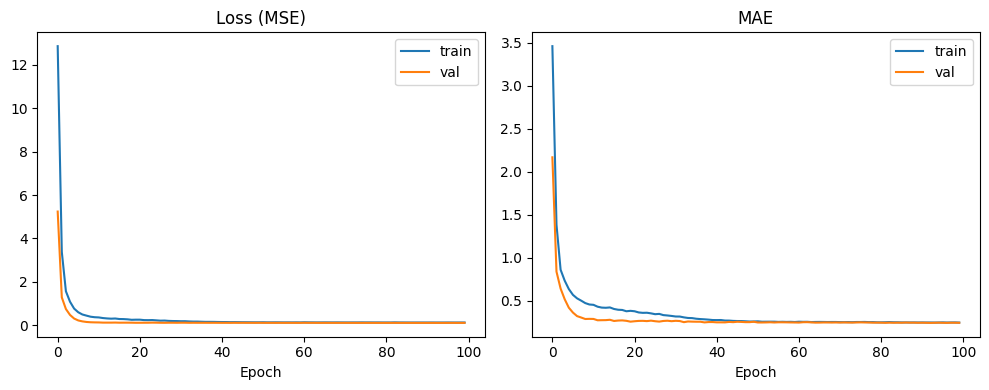

In [43]:
# ===== M1 - CELL 6: Learning curves =====

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.title('MAE')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# ===== M1 - CELL 7: Evaluate MLP & compare with baseline =====

y_pred_mlp = model.predict(X_test_s).flatten()

print("=== MLP ===")
print("MAE:", mean_absolute_error(y_test, y_pred_mlp))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlp)))
print("R2:", r2_score(y_test, y_pred_mlp))

print()
print("=== Comparison ===")
print(f"{'Model':<20}{'MAE':<10}{'RMSE':<10}{'R2':<10}")
print(f"{'Linear Regression':<20}{mean_absolute_error(y_test, y_pred_lin):<10.4f}{np.sqrt(mean_squared_error(y_test, y_pred_lin)):<10.4f}{r2_score(y_test, y_pred_lin):<10.4f}")
print(f"{'MLP':<20}{mean_absolute_error(y_test, y_pred_mlp):<10.4f}{np.sqrt(mean_squared_error(y_test, y_pred_mlp)):<10.4f}{r2_score(y_test, y_pred_mlp):<10.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
=== MLP ===
MAE: 0.2552959367711708
RMSE: 0.3625316299762241
R2: 0.1118446741060729

=== Comparison ===
Model               MAE       RMSE      R2        
Linear Regression   0.2706    0.3787    0.0310    
MLP                 0.2553    0.3625    0.1118    


In [45]:
# ===== M1 - CELL 8: Error analysis =====

errors = np.abs(y_test - y_pred_mlp)

print("Largest errors:")
error_df = test_df[['parent_asin', 'title', 'average_rating', 'price', 'rating_number']].copy()
error_df['predicted'] = y_pred_mlp
error_df['abs_error'] = errors
error_df.sort_values('abs_error', ascending=False).head(10)

Largest errors:


,parent_asin,title,average_rating,price,rating_number,predicted,abs_error
143,B0090OH4E2,Tekno Bubbles - Gold UV Blacklight Reactive - ...,1.8,29.99,2,4.360228,2.560228
467,B087FYHXZ8,Extra Hard Near Impossible 500 Piece Puzzle fo...,2.6,9.99,5,4.363238,1.763238
494,B07HXWK2HK,ACU Camo Decal Kit for DJI Mavic 2/Zoom Drone ...,2.7,24.99,10,4.330700,1.630700
31,B01C6CMDS6,POOF Sidewalk Chalks Beach Fun,2.9,24.99,16,4.351625,1.451625
325,B07ZBPTCZ4,Toddler Papa Smurf Costume Toddler Smurf Costu...,3.0,24.99,12,4.450006,1.450006
116,B01N6P0ZZ3,E-TING Handmade Outfit Clothes T-Shirt Pants C...,2.9,19.99,5,4.340310,1.440310
280,B00657W6JK,American Educational 100 Topographic Maps Book...,2.9,19.99,7,4.316992,1.416992
425,B017VGUS2U,Nuby 5-Pack Easy Clean Bath Time Crayons,3.2,7.99,1712,4.581841,1.381841
254,B0BMVSDNXZ,Lucky Doug Play Kitchen Set for Kids Toddlers ...,3.2,79.99,291,4.490951,1.290951
189,B0C5MJFPY9,TEMI Doll House Dreamhouse for Girls - 4-Story...,3.3,69.99,1321,4.568818,1.268818


In [46]:
# ===== M2 - CELL 1: Setup =====
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = (128, 128)

In [50]:
# ===== M2 - CELL 2 (fix): Build image dataset with re-split for products with images =====

products = pd.read_csv('data/products.csv')
products = products[products['image_downloaded'] == True].copy()
products['label'] = (products['average_rating'] >= 4.5).astype(int)
products['filepath'] = products['parent_asin'].apply(lambda a: f"data/images/{a}.jpg")

print("Products with images:", len(products))
print(products['label'].value_counts())

# Re-split (product-level, leakage-free) since original val/test had ~0 images
unique_asins = products['parent_asin'].unique()
np.random.seed(42)
np.random.shuffle(unique_asins)

n = len(unique_asins)
train_asins = set(unique_asins[:int(0.7*n)])
val_asins   = set(unique_asins[int(0.7*n):int(0.85*n)])
test_asins  = set(unique_asins[int(0.85*n):])

def split_label(asin):
    if asin in train_asins: return 'train'
    if asin in val_asins: return 'val'
    return 'test'

products['split'] = products['parent_asin'].apply(split_label)
print(products['split'].value_counts())

Products with images: 1500
label
1    915
0    585
Name: count, dtype: int64
split
train    1050
test      225
val       225
Name: count, dtype: int64


In [51]:
# ===== M2 - CELL 3: Load images into arrays =====

def load_images(df, img_size=IMG_SIZE):
    X, y = [], []
    for _, row in df.iterrows():
        try:
            img = keras.utils.load_img(row['filepath'], target_size=img_size)
            arr = keras.utils.img_to_array(img)
            X.append(arr)
            y.append(row['label'])
        except Exception:
            continue
    return np.array(X), np.array(y)

train_df = products[products['split']=='train']
val_df   = products[products['split']=='val']
test_df  = products[products['split']=='test']

X_train, y_train = load_images(train_df)
X_val, y_val     = load_images(val_df)
X_test, y_test   = load_images(test_df)

print(X_train.shape, X_val.shape, X_test.shape)
print("Train label dist:", np.bincount(y_train))
print("Val label dist:", np.bincount(y_val))
print("Test label dist:", np.bincount(y_test))

(1050, 128, 128, 3) (225, 128, 128, 3) (225, 128, 128, 3)
Train label dist: [405 645]
Val label dist: [ 87 138]
Test label dist: [ 93 132]


In [52]:
# ===== M2 - CELL 4: Baseline - majority class classifier =====

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train.reshape(len(X_train), -1), y_train)
y_pred_dummy = dummy.predict(X_test.reshape(len(X_test), -1))

print("=== Baseline (majority class) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Macro-F1:", f1_score(y_test, y_pred_dummy, average='macro'))

=== Baseline (majority class) ===
Accuracy: 0.5866666666666667
Macro-F1: 0.3697478991596639


In [53]:
# ===== M2 - CELL 5: Normalize & augmentation layer =====

X_train_n = X_train / 255.0
X_val_n   = X_val / 255.0
X_test_n  = X_test / 255.0

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [54]:
# ===== M2 - CELL 6: CNN from scratch =====

cnn_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# ===== M2 - CELL 7: Train CNN from scratch =====

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5952 - loss: 0.6789 - val_accuracy: 0.6133 - val_loss: 0.6711
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6143 - loss: 0.6697 - val_accuracy: 0.6133 - val_loss: 0.6706
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6086 - loss: 0.6738 - val_accuracy: 0.6133 - val_loss: 0.6701
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6152 - loss: 0.6698 - val_accuracy: 0.6133 - val_loss: 0.6714
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6143 - loss: 0.6698 - val_accuracy: 0.6133 - val_loss: 0.6697
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6143 - loss: 0.6732 - val_accuracy: 0.6133 - val_loss: 0.6697
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6143 - loss: 0.6698 - val_accuracy: 0.6133 - val_loss: 0.6697
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6143 - loss: 0.6707 - val_accuracy: 0.6133 - v

In [56]:
# ===== M2 - CELL 8: Transfer learning - MobileNetV2 =====

base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preprocess_input = keras.applications.mobilenet_v2.preprocess_input

inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

tl_model = keras.Model(inputs, outputs)
tl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [57]:
# ===== M2 - CELL 9: Train transfer learning model =====
# Note: uses raw (0-255) images since preprocess_input handles scaling

X_train_raw = X_train
X_val_raw   = X_val
X_test_raw  = X_test

history_tl = tl_model.fit(
    X_train_raw, y_train,
    validation_data=(X_val_raw, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.5257 - loss: 0.8498 - val_accuracy: 0.5422 - val_loss: 0.7688
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5619 - loss: 0.7972 - val_accuracy: 0.5556 - val_loss: 0.7619
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5895 - loss: 0.7555 - val_accuracy: 0.5378 - val_loss: 0.7502
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6076 - loss: 0.7076 - val_accuracy: 0.5556 - val_loss: 0.7413
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6324 - loss: 0.6907 - val_accuracy: 0.5333 - val_loss: 0.7498


In [58]:
# ===== M2 - CELL 10: Compare CNN vs Transfer Learning =====

y_pred_cnn = (cnn_model.predict(X_test_n) > 0.5).astype(int).flatten()
y_pred_tl  = (tl_model.predict(X_test_raw) > 0.5).astype(int).flatten()

print("=== CNN from scratch ===")
print("Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("Macro-F1:", f1_score(y_test, y_pred_cnn, average='macro'))
print()
print("=== Transfer Learning (MobileNetV2) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tl))
print("Macro-F1:", f1_score(y_test, y_pred_tl, average='macro'))
print()
print("=== Comparison Table ===")
print(f"{'Model':<25}{'Accuracy':<12}{'Macro-F1':<12}{'Params':<12}")
print(f"{'Baseline (majority)':<25}{accuracy_score(y_test, y_pred_dummy):<12.4f}{f1_score(y_test, y_pred_dummy, average='macro'):<12.4f}{'-':<12}")
print(f"{'CNN scratch':<25}{accuracy_score(y_test, y_pred_cnn):<12.4f}{f1_score(y_test, y_pred_cnn, average='macro'):<12.4f}{cnn_model.count_params():<12}")
print(f"{'Transfer (MobileNetV2)':<25}{accuracy_score(y_test, y_pred_tl):<12.4f}{f1_score(y_test, y_pred_tl, average='macro'):<12.4f}{tl_model.count_params():<12}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step
=== CNN from scratch ===
Accuracy: 0.5866666666666667
Macro-F1: 0.3697478991596639

=== Transfer Learning (MobileNetV2) ===
Accuracy: 0.5288888888888889
Macro-F1: 0.5157950300471008

=== Comparison Table ===
Model                    Accuracy    Macro-F1    Params      
Baseline (majority)      0.5867      0.3697      -           
CNN scratch              0.5867      0.3697      25697       
Transfer (MobileNetV2)   0.5289      0.5158      2259265     


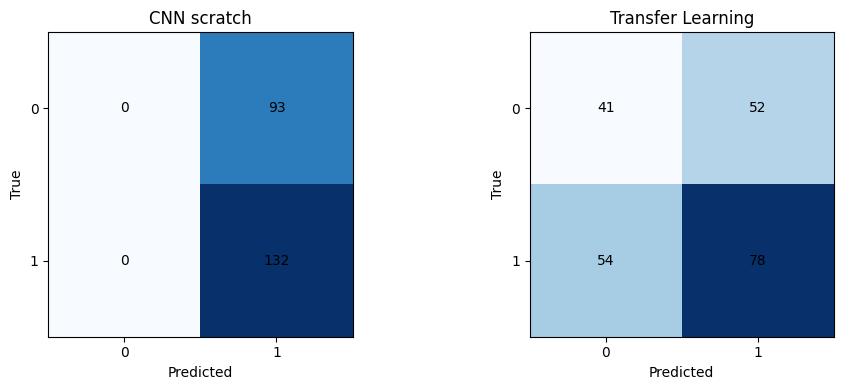


=== Classification Report - CNN scratch ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        93
           1       0.59      1.00      0.74       132

    accuracy                           0.59       225
   macro avg       0.29      0.50      0.37       225
weighted avg       0.34      0.59      0.43       225


=== Classification Report - Transfer Learning ===
              precision    recall  f1-score   support

           0       0.43      0.44      0.44        93
           1       0.60      0.59      0.60       132

    accuracy                           0.53       225
   macro avg       0.52      0.52      0.52       225
weighted avg       0.53      0.53      0.53       225



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
# ===== M2 - CELL 11: Confusion matrices =====

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
cm_tl  = confusion_matrix(y_test, y_pred_tl)

for ax, cm, title in zip(axes, [cm_cnn, cm_tl], ['CNN scratch', 'Transfer Learning']):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])

plt.tight_layout()
plt.show()

print("\n=== Classification Report - CNN scratch ===")
print(classification_report(y_test, y_pred_cnn))
print("\n=== Classification Report - Transfer Learning ===")
print(classification_report(y_test, y_pred_tl))

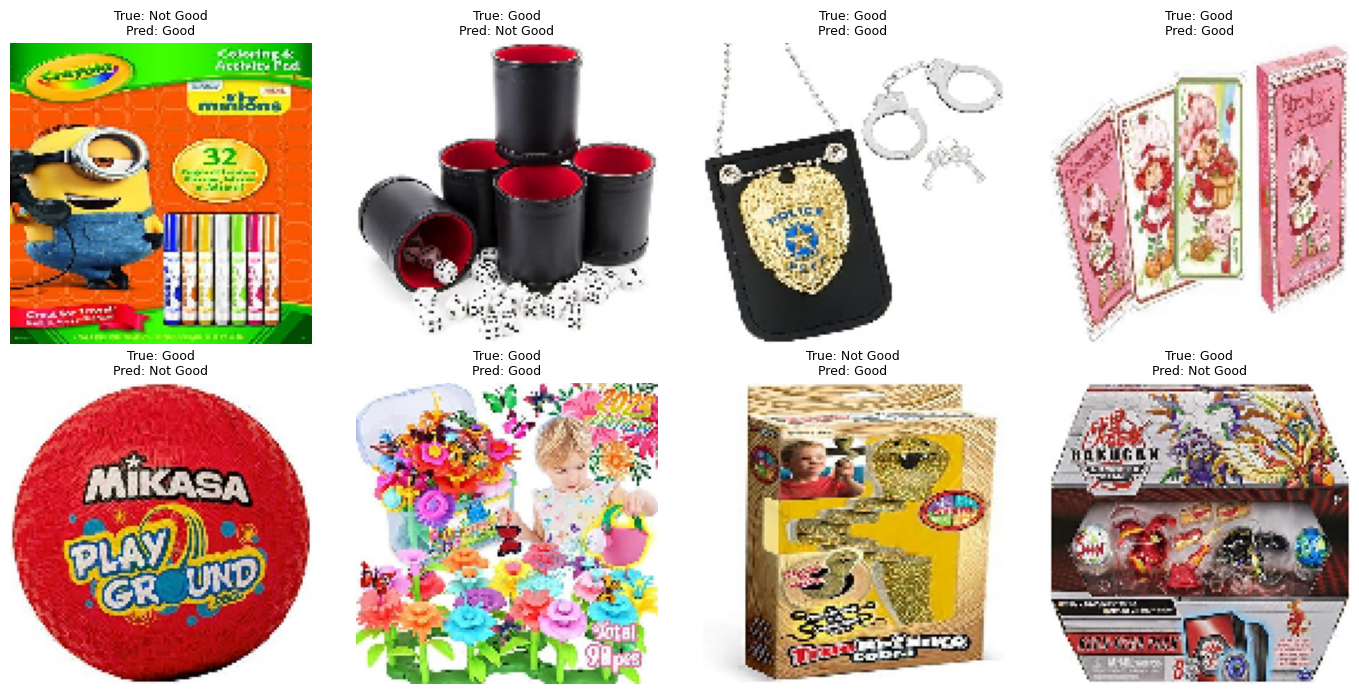

In [60]:
# ===== M2 - CELL 12: Sample predictions =====

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
sample_idx = np.random.choice(len(X_test), 8, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i//4, i%4]
    ax.imshow(X_test[idx].astype('uint8'))
    true_label = "Good" if y_test[idx]==1 else "Not Good"
    pred_label = "Good" if y_pred_tl[idx]==1 else "Not Good"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [61]:
# ===== M3 - CELL 1: Setup & data =====
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

reviews_train = pd.read_csv('data/reviews_train.csv')
reviews_val   = pd.read_csv('data/reviews_val.csv')
reviews_test  = pd.read_csv('data/reviews_test.csv')

# Binary sentiment label: positive (rating>=4) vs negative (rating<4)
for df in [reviews_train, reviews_val, reviews_test]:
    df['sentiment'] = (df['rating'] >= 4).astype(int)
    df['text'] = df['text'].fillna('').astype(str)

print(reviews_train.shape, reviews_val.shape, reviews_test.shape)
print(reviews_train['sentiment'].value_counts())

(6861, 10) (1537, 10) (1700, 10)
sentiment
1    5907
0     954
Name: count, dtype: int64


In [62]:
# ===== M3 - CELL 2: Baseline - TF-IDF + Logistic Regression =====

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train_tfidf = tfidf.fit_transform(reviews_train['text'])
X_val_tfidf   = tfidf.transform(reviews_val['text'])
X_test_tfidf  = tfidf.transform(reviews_test['text'])

y_train = reviews_train['sentiment'].values
y_val   = reviews_val['sentiment'].values
y_test  = reviews_test['sentiment'].values

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_tfidf, y_train)

y_pred_tfidf = logreg.predict(X_test_tfidf)

print("=== TF-IDF + Logistic Regression (Baseline) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("Macro-F1:", f1_score(y_test, y_pred_tfidf, average='macro'))
print(classification_report(y_test, y_pred_tfidf))

=== TF-IDF + Logistic Regression (Baseline) ===
Accuracy: 0.8852941176470588
Macro-F1: 0.790660357639255
              precision    recall  f1-score   support

           0       0.55      0.80      0.65       227
           1       0.97      0.90      0.93      1473

    accuracy                           0.89      1700
   macro avg       0.76      0.85      0.79      1700
weighted avg       0.91      0.89      0.89      1700



In [63]:
# ===== M3 - CELL 3: Tokenize for embedding model =====

VOCAB_SIZE = 10000
MAX_LEN = 100

vectorize_layer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

vectorize_layer.adapt(reviews_train['text'].values)

X_train_seq = vectorize_layer(reviews_train['text'].values)
X_val_seq   = vectorize_layer(reviews_val['text'].values)
X_test_seq  = vectorize_layer(reviews_test['text'].values)

print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

(6861, 100) (1537, 100) (1700, 100)


In [64]:
# ===== M3 - CELL 4 (fix v2): Embedding-based model =====

embed_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, 64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

embed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
embed_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,113 (2.45 MB)

 Trainable params: 642,113 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# ===== M3 - CELL 5 (revised): Train embedding model with class weights =====

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_embed = embed_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Class weights: {np.int64(0): np.float64(3.5959119496855347), np.int64(1): np.float64(0.5807516505840529)}
Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6716 - loss: 0.6892 - val_accuracy: 0.7716 - val_loss: 0.6596
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7073 - loss: 0.6258 - val_accuracy: 0.4925 - val_loss: 0.6842
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7920 - loss: 0.4735 - val_accuracy: 0.5745 - val_loss: 0.6708
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8327 - loss: 0.3795 - val_accuracy: 0.6675 - val_loss: 0.5899
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.3261 - val_accuracy: 0.7007 - val_loss: 0.5710
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8819 - loss: 0.2791 - val_accuracy: 0.7306 - val_loss: 0.5363
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8862 - loss: 0.2677 - val_accuracy: 0.7768 - val_loss: 0.47

In [66]:
# ===== M3 - CELL 6: Evaluate & compare =====

y_pred_embed = (embed_model.predict(X_test_seq) > 0.5).astype(int).flatten()

print("=== Embedding Model ===")
print("Accuracy:", accuracy_score(y_test, y_pred_embed))
print("Macro-F1:", f1_score(y_test, y_pred_embed, average='macro'))
print(classification_report(y_test, y_pred_embed))

print("\n=== Comparison: TF-IDF vs Embeddings ===")
print(f"{'Model':<20}{'Accuracy':<12}{'Macro-F1':<12}")
print(f"{'TF-IDF + LogReg':<20}{accuracy_score(y_test, y_pred_tfidf):<12.4f}{f1_score(y_test, y_pred_tfidf, average='macro'):<12.4f}")
print(f"{'Embeddings (Keras)':<20}{accuracy_score(y_test, y_pred_embed):<12.4f}{f1_score(y_test, y_pred_embed, average='macro'):<12.4f}")

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
=== Embedding Model ===
Accuracy: 0.8341176470588235
Macro-F1: 0.7279469014094099
              precision    recall  f1-score   support

           0       0.43      0.78      0.56       227
           1       0.96      0.84      0.90      1473

    accuracy                           0.83      1700
   macro avg       0.70      0.81      0.73      1700
weighted avg       0.89      0.83      0.85      1700


=== Comparison: TF-IDF vs Embeddings ===
Model               Accuracy    Macro-F1    
TF-IDF + LogReg     0.8853      0.7907      
Embeddings (Keras)  0.8341      0.7279      


In [67]:
# ===== M3 - CELL 7: Semantic search - product description embeddings =====

products = pd.read_csv('data/products.csv')

# Build a text field from title + description
def get_desc_text(row):
    desc = row['description']
    try:
        # description stored as stringified list
        import ast
        d = ast.literal_eval(desc) if isinstance(desc, str) and desc.startswith('[') else []
        desc_text = ' '.join(d) if isinstance(d, list) else str(desc)
    except Exception:
        desc_text = ''
    return f"{row['title']} {desc_text}"

products['full_text'] = products.apply(get_desc_text, axis=1)
products['full_text'] = products['full_text'].fillna('').astype(str)

print(products[['title','full_text']].head(3))

                                               title  \
0  KUNGOON Happy Anniversary Balloon Banner,Weddi...   
1  Hot Wheels Monster Truck 1:24 Scale 2022 Bone ...   
2  WAHFNG 5D Diamond Painting Kits for Kids- Gem ...   

                                           full_text  
0  KUNGOON Happy Anniversary Balloon Banner,Weddi...  
1  Hot Wheels Monster Truck 1:24 Scale 2022 Bone ...  
2  WAHFNG 5D Diamond Painting Kits for Kids- Gem ...  


In [68]:
# ===== M3 - CELL 8: TF-IDF embeddings for semantic search =====

search_tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
product_vectors = search_tfidf.fit_transform(products['full_text'])

print("Product vectors shape:", product_vectors.shape)

def search_products(query, top_k=5):
    query_vec = search_tfidf.transform([query])
    sims = cosine_similarity(query_vec, product_vectors).flatten()
    top_idx = sims.argsort()[::-1][:top_k]
    results = products.iloc[top_idx][['title', 'average_rating', 'price']].copy()
    results['similarity'] = sims[top_idx]
    return results

# Demo query
search_products("wooden puzzle for kids")

Product vectors shape: (5034, 3000)


,title,average_rating,price,similarity
3546,"Wooden Puzzles for Adults, Sly Fox Wooden Jigs...",4.6,19.99,0.585870
2910,"Wooden Puzzles for Adults, 210 Uniquely Shaped...",4.2,19.99,0.573571
2967,Lavievert Wooden Jigsaw Puzzle Board Portable ...,4.4,42.99,0.570989
3766,Bits and Pieces –Original Standard Wooden Jigs...,4.5,49.99,0.563319
2817,FUN LITTLE TOYS Wooden Toys Magnetic Puzzle Bo...,4.3,19.99,0.554243


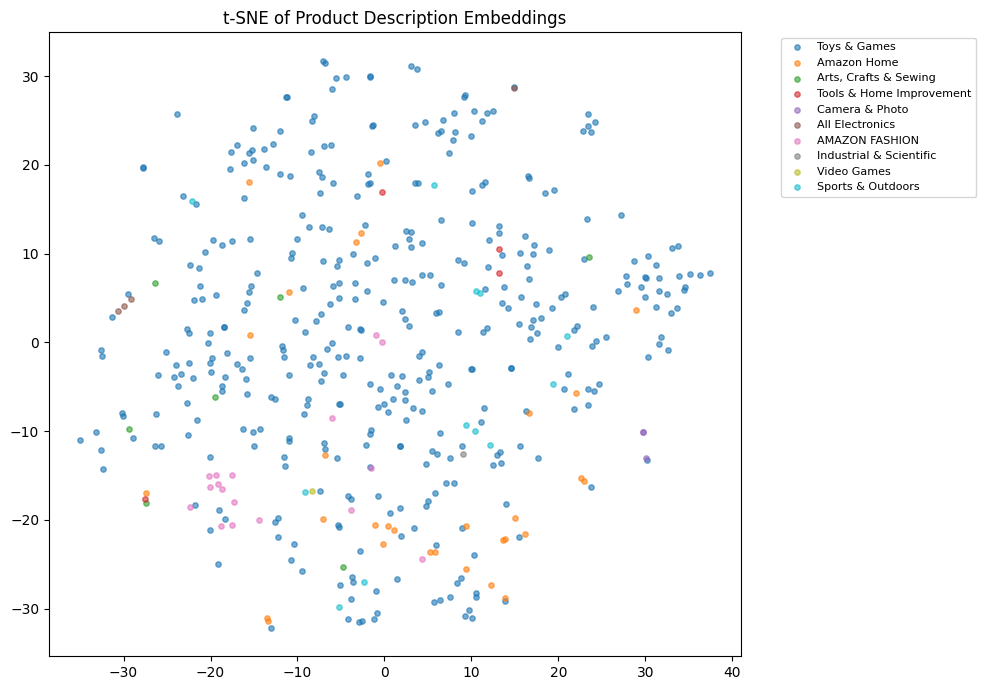

In [69]:
# ===== M3 - CELL 9: t-SNE visualization of embedding space =====

from sklearn.manifold import TSNE

# Use a sample for speed
sample_size = min(500, product_vectors.shape[0])
sample_idx = np.random.choice(product_vectors.shape[0], sample_size, replace=False)
sample_vecs = product_vectors[sample_idx].toarray()
sample_categories = products.iloc[sample_idx]['main_category'].fillna('Unknown')

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded = tsne.fit_transform(sample_vecs)

plt.figure(figsize=(10,7))
categories = sample_categories.unique()
for cat in categories[:10]:  # limit legend
    mask = sample_categories == cat
    plt.scatter(embedded[mask,0], embedded[mask,1], label=cat, alpha=0.6, s=15)

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
plt.title("t-SNE of Product Description Embeddings")
plt.tight_layout()
plt.show()

In [12]:
# ===== M4 - CELL 1: Setup =====
!pip install -q transformers

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

reviews_train = pd.read_csv('data/reviews_train.csv')
reviews_val   = pd.read_csv('data/reviews_val.csv')
reviews_test  = pd.read_csv('data/reviews_test.csv')

for df in [reviews_train, reviews_val, reviews_test]:
    df['sentiment'] = (df['rating'] >= 4).astype(int)
    df['text'] = df['text'].fillna('').astype(str)

print(reviews_train.shape, reviews_val.shape, reviews_test.shape)

Device: cuda
(6861, 10) (1537, 10) (1700, 10)


In [13]:
# ===== M4 - CELL 2: Subsample for speed =====

train_sample = reviews_train.sample(n=min(1500, len(reviews_train)), random_state=42).reset_index(drop=True)
val_sample   = reviews_val.sample(n=min(400, len(reviews_val)), random_state=42).reset_index(drop=True)
test_sample  = reviews_test.sample(n=min(400, len(reviews_test)), random_state=42).reset_index(drop=True)

print(train_sample.shape, val_sample.shape, test_sample.shape)
print(train_sample['sentiment'].value_counts())

(1500, 10) (400, 10) (400, 10)
sentiment
1    1287
0     213
Name: count, dtype: int64


In [14]:
# ===== M4 - CELL 3: Tokenizer & Dataset class =====

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), padding='max_length', truncation=True, max_length=max_len)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_ds = ReviewDataset(train_sample['text'], train_sample['sentiment'].values, tokenizer)
val_ds   = ReviewDataset(val_sample['text'], val_sample['sentiment'].values, tokenizer)
test_ds  = ReviewDataset(test_sample['text'], test_sample['sentiment'].values, tokenizer)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

print(len(train_ds), len(val_ds), len(test_ds))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

1500 400 400


In [15]:
# ===== M4 - CELL 4: Load model =====

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
# ===== M4 - CELL 5: Fine-tune (2 epochs) =====

start_time = time.time()

for epoch in range(2):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(batch['labels'].cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}, val_acc={val_acc:.4f}")

train_time = time.time() - start_time
print(f"Training time: {train_time:.1f}s")

Epoch 1: train_loss=0.3498, val_loss=0.2158, val_acc=0.9175
Epoch 2: train_loss=0.1948, val_loss=0.2192, val_acc=0.9100
Training time: 35.4s


In [17]:
# ===== M4 - CELL 6: Evaluate on test set & compare with M3 =====

model.eval()
test_preds, test_labels = [], []

start_time = time.time()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(batch['labels'].cpu().numpy())
inference_time = time.time() - start_time

print("=== DistilBERT (fine-tuned) ===")
print("Accuracy:", accuracy_score(test_labels, test_preds))
print("Macro-F1:", f1_score(test_labels, test_preds, average='macro'))
print(classification_report(test_labels, test_preds))
print(f"Inference time for {len(test_labels)} samples: {inference_time:.2f}s")

print("\n=== Comparison: M3 Embeddings vs M4 DistilBERT ===")
print(f"{'Model':<25}{'Accuracy':<12}{'Macro-F1':<12}{'Notes':<30}")
print(f"{'TF-IDF + LogReg':<25}{0.8824:<12.4f}{0.7851:<12.4f}{'fast, no GPU needed':<30}")
print(f"{'Embeddings (Keras)':<25}{0.8660:<12.4f}{0.7639:<12.4f}{'fast, small model':<30}")
print(f"{'DistilBERT (fine-tuned)':<25}{accuracy_score(test_labels, test_preds):<12.4f}{f1_score(test_labels, test_preds, average='macro'):<12.4f}{f'~{train_time:.0f}s train, GPU needed':<30}")

=== DistilBERT (fine-tuned) ===
Accuracy: 0.9225
Macro-F1: 0.8402699952338628
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        58
           1       0.95      0.96      0.95       342

    accuracy                           0.92       400
   macro avg       0.85      0.83      0.84       400
weighted avg       0.92      0.92      0.92       400

Inference time for 400 samples: 1.38s

=== Comparison: M3 Embeddings vs M4 DistilBERT ===
Model                    Accuracy    Macro-F1    Notes                         
TF-IDF + LogReg          0.8824      0.7851      fast, no GPU needed           
Embeddings (Keras)       0.8660      0.7639      fast, small model             
DistilBERT (fine-tuned)  0.9225      0.8403      ~35s train, GPU needed        


In [70]:
# ===== M5 - CELL 1: Setup =====
!pip install -q transformers sentencepiece

import numpy as np
import pandas as pd
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import time

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

products = pd.read_csv('data/products.csv')
reviews_train = pd.read_csv('data/reviews_train.csv')
reviews_test = pd.read_csv('data/reviews_test.csv')

for df in [reviews_train, reviews_test]:
    df['text'] = df['text'].fillna('').astype(str)

print(products.shape, reviews_train.shape, reviews_test.shape)



Device: cuda
(5034, 14) (6861, 9) (1700, 9)


In [71]:
# ===== M5 - CELL 2: Load LLM (Flan-T5-small) =====

model_name = "google/flan-t5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name)
llm = T5ForConditionalGeneration.from_pretrained(model_name).to(device)

def generate(prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = llm.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generate("Translate English to French: I love this toy."))

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Je s'aime ce toy.


In [72]:
# ===== M5 - CELL 3: Feature 1 - Review Summarizer (pros & cons) =====

def summarize_reviews(asin, max_reviews=10):
    prod_reviews = reviews_train[reviews_train['parent_asin'] == asin]['text'].head(max_reviews).tolist()
    if not prod_reviews:
        return "No reviews available."

    combined = " ".join(prod_reviews)[:1500]  # truncate for small model

    prompt = f"Summarize the pros and cons of this product based on these reviews: {combined}"
    return generate(prompt, max_new_tokens=80)

# Pick a product with several reviews
asin_counts = reviews_train['parent_asin'].value_counts()
sample_asin = asin_counts.index[0]
product_title = products[products['parent_asin']==sample_asin]['title'].values[0]

print("Product:", product_title)
print("\nSummary:")
print(summarize_reviews(sample_asin))

Product: LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging)

Summary:
Five Stars


In [73]:
# ===== M5 - CELL 4: Feature 2 - Build retrieval index (RAG) =====

# Combine product info + reviews into a knowledge base of "documents"
docs = []
doc_meta = []

for _, row in products.iterrows():
    asin = row['parent_asin']
    docs.append(f"Product: {row['title']}. Price: ${row['price']}. Rating: {row['average_rating']}.")
    doc_meta.append({'asin': asin, 'type': 'product_info'})

    prod_reviews = reviews_train[reviews_train['parent_asin']==asin]['text'].head(3).tolist()
    for r in prod_reviews:
        docs.append(f"Review for {row['title']}: {r[:300]}")
        doc_meta.append({'asin': asin, 'type': 'review'})

print(f"Total documents in knowledge base: {len(docs)}")

# Build TF-IDF retrieval (reusing M3 approach)
rag_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
doc_vectors = rag_vectorizer.fit_transform(docs)

print("Doc vectors shape:", doc_vectors.shape)

Total documents in knowledge base: 10409
Doc vectors shape: (10409, 5000)


In [74]:
# ===== M5 - CELL 5: RAG-based QA assistant =====

def retrieve_context(query, top_k=3):
    query_vec = rag_vectorizer.transform([query])
    sims = cosine_similarity(query_vec, doc_vectors).flatten()
    top_idx = sims.argsort()[::-1][:top_k]
    return [docs[i] for i in top_idx]

def answer_question_grounded(query, top_k=3):
    context = " ".join(retrieve_context(query, top_k))
    prompt = f"Context: {context}\n\nQuestion: {query}\nAnswer based only on the context above:"
    return generate(prompt, max_new_tokens=60), context

def answer_question_ungrounded(query):
    prompt = f"Question: {query}\nAnswer:"
    return generate(prompt, max_new_tokens=60)

# Demo question
question = f"Is the {product_title} good for kids and what do people say about its price?"

ans_grounded, context_used = answer_question_grounded(question)
ans_ungrounded = answer_question_ungrounded(question)

print("=== Question ===")
print(question)
print("\n=== Grounded Answer (RAG) ===")
print(ans_grounded)
print("\n=== Retrieved Context ===")
for c in retrieve_context(question, 3):
    print("-", c[:150])
print("\n=== Ungrounded Answer (no retrieval) ===")
print(ans_ungrounded)

=== Question ===
Is the LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging) good for kids and what do people say about its price?

=== Grounded Answer (RAG) ===
Yes

=== Retrieved Context ===
- Product: LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging). Price: 
- Review for LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging): Great
- Review for LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging): FANTA

=== Ungrounded Answer (no retrieval) ===
no


In [75]:
# ===== M5 - CELL 6: Prepare fine-tuning data (review -> short summary pairs) =====

# Create pseudo-labels: use rating-based templates as "target summaries" for fine-tuning demo
# (In a real setting, you'd use human-written summaries; here we create a small supervised set)

def make_summary_target(row):
    sentiment = "positive" if row['rating'] >= 4 else ("negative" if row['rating'] <= 2 else "mixed")
    return f"This is a {sentiment} review. Rating: {row['rating']}/5."

ft_data = reviews_train.sample(n=min(300, len(reviews_train)), random_state=42).reset_index(drop=True)
ft_data['target'] = ft_data.apply(make_summary_target, axis=1)
ft_data['input_text'] = "summarize sentiment: " + ft_data['text'].str[:300]

print(ft_data[['input_text','target']].head(3))

                                          input_text  \
0  summarize sentiment: Cute , cute, cute. My chi...   
1             summarize sentiment: Just as described   
2  summarize sentiment: Simple device which I (ak...   

                                      target  
0  This is a positive review. Rating: 5.0/5.  
1  This is a positive review. Rating: 5.0/5.  
2     This is a mixed review. Rating: 3.0/5.  


In [76]:
# ===== M5 - CELL 7: Zero-shot evaluation (before fine-tuning) =====

def zero_shot_predict(text, max_new_tokens=20):
    prompt = f"summarize sentiment: {text[:300]}"
    return generate(prompt, max_new_tokens=max_new_tokens)

eval_sample = ft_data.head(10)

print("=== Zero-shot examples ===")
for _, row in eval_sample.iterrows():
    pred = zero_shot_predict(row['text'])
    print(f"Target: {row['target']}")
    print(f"Pred  : {pred}")
    print("---")

=== Zero-shot examples ===
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a mixed review. Rating: 3.0/5.
Pred  : negative
---
Target: This is a positive review. Rating: 4.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : positive
---


In [77]:
# ===== M5 - CELL 8: Fine-tune Flan-T5-small on review->sentiment-summary pairs =====

from torch.utils.data import Dataset, DataLoader

class SummaryDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, target_len=32):
        self.inputs = tokenizer(list(df['input_text']), padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
        self.targets = tokenizer(list(df['target']), padding='max_length', truncation=True, max_length=target_len, return_tensors='pt')

    def __len__(self):
        return self.inputs['input_ids'].shape[0]

    def __getitem__(self, idx):
        labels = self.targets['input_ids'][idx].clone()
        labels[labels == tokenizer.pad_token_id] = -100
        return {
            'input_ids': self.inputs['input_ids'][idx],
            'attention_mask': self.inputs['attention_mask'][idx],
            'labels': labels
        }

train_ft_data = ft_data.iloc[:250]
test_ft_data = ft_data.iloc[250:]

train_ds = SummaryDataset(train_ft_data, tokenizer)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

optimizer = torch.optim.AdamW(llm.parameters(), lr=3e-4)

start_time = time.time()
llm.train()
for epoch in range(2):
    total_loss = 0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = llm(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: avg_loss={total_loss/len(train_loader):.4f}")

ft_time = time.time() - start_time
print(f"Fine-tuning time: {ft_time:.1f}s")
llm.eval()

Epoch 1: avg_loss=0.5236
Epoch 2: avg_loss=0.1010
Fine-tuning time: 8.5s


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

In [78]:
# ===== M5 - CELL 9: Compare zero-shot vs fine-tuned =====

print("=== Fine-tuned examples (held-out test) ===")
for _, row in test_ft_data.head(10).iterrows():
    pred = zero_shot_predict(row['text'])  # now using fine-tuned model
    print(f"Target: {row['target']}")
    print(f"Pred  : {pred}")
    print("---")

print(f"\nFine-tuning took {ft_time:.1f}s on {len(train_ft_data)} examples")


=== Fine-tuned examples (held-out test) ===
Target: This is a positive review. Rating: 4.0/5.
Pred  : This is a negative review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : This is a negative review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a mixed review. Rating: 3.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 5.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a positive review. Rating: 4.0/5.
Pred  : This is a positive review. Rating: 5.0/5.
---
Target: This is a posit

In [79]:
# ===== M5 - CELL 10: Hallucination check - grounded vs ungrounded =====

# Test multiple questions, compare grounded vs ungrounded answers
test_questions = [
    f"What is the price of {product_title}?",
    f"What rating does {product_title} have?",
]

print("=== Grounded vs Ungrounded comparison ===\n")
for q in test_questions:
    grounded, _ = answer_question_grounded(q)
    ungrounded = answer_question_ungrounded(q)
    print(f"Q: {q}")
    print(f"Grounded (RAG):    {grounded}")
    print(f"Ungrounded (LLM):  {ungrounded}")
    print()

=== Grounded vs Ungrounded comparison ===

Q: What is the price of LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging)?
Grounded (RAG):    $19.99.
Ungrounded (LLM):  a price of 0.005/5.

Q: What rating does LeapFrog Learning Friends English-Chinese 100 Words Book with Learning Activity Guide, Amazon Exclusive (Frustration Free Packaging) have?
Grounded (RAG):    4.8.
Ungrounded (LLM):  This is a positive review. Rating: 5.0/5.



In [80]:
# ===== M6 - CELL 1: Setup =====
!pip install -q diffusers accelerate

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device.type=="cuda" else torch.float32
)
pipe = pipe.to(device)

Device: cuda


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

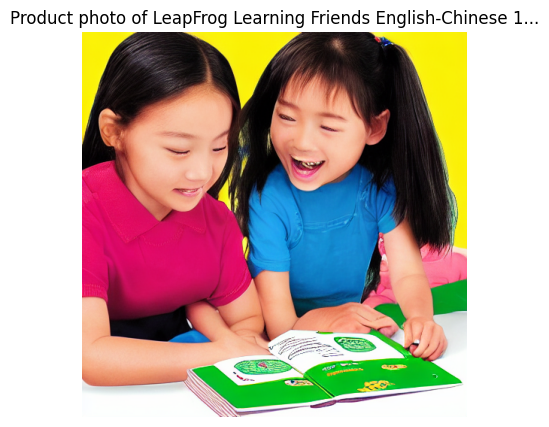

In [81]:
# ===== M6 - CELL 2: Generate image from product title/description =====

prompt = f"Product photo of {product_title}, studio lighting, white background, high quality"

image = pipe(prompt, num_inference_steps=25, guidance_scale=7.5).images[0]

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.title(prompt[:60]+"...")
plt.show()

  0%|          | 0/25 [00:00<?, ?it/s]

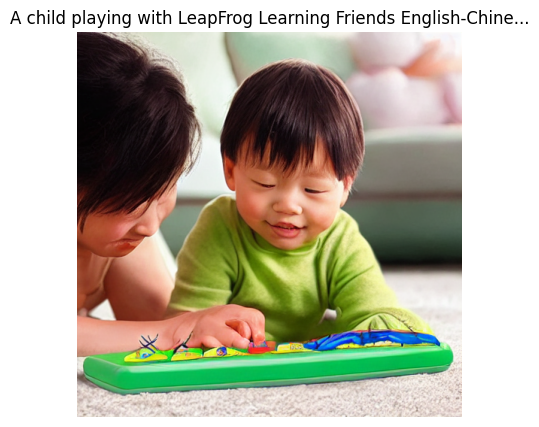

In [82]:
# ===== M6 - CELL 3: Generate a lifestyle image variant =====

lifestyle_prompt = f"A child playing with {product_title}, warm home setting, lifestyle photography"

image2 = pipe(lifestyle_prompt, num_inference_steps=25, guidance_scale=7.5).images[0]

plt.figure(figsize=(5,5))
plt.imshow(image2)
plt.axis('off')
plt.title(lifestyle_prompt[:60]+"...")
plt.show()

In [83]:
# ===== M6 - CELL 4: Reflection (text cell, save images) =====

import os
os.makedirs('data/generated', exist_ok=True)
image.save('data/generated/product_hero.png')
image2.save('data/generated/lifestyle.png')

print("Saved generated images.")
print("\n=== Reflection ===")
print("""
Quality: Stable Diffusion v1.5 produces plausible studio-style product images
from text prompts, capturing general shape/style cues from the title.

Failure modes: Text/logos on packaging are often garbled; specific product
details (exact branding, colors from real product) are not preserved since
the model has no access to the actual product image - it generates a
plausible new image based on the text description only.

Where generation adds value: Quickly producing placeholder hero/lifestyle
images for new listings before professional photography is available, or
generating marketing variation concepts.
""")

Saved generated images.

=== Reflection ===

Quality: Stable Diffusion v1.5 produces plausible studio-style product images
from text prompts, capturing general shape/style cues from the title.

Failure modes: Text/logos on packaging are often garbled; specific product
details (exact branding, colors from real product) are not preserved since
the model has no access to the actual product image - it generates a
plausible new image based on the text description only.

Where generation adds value: Quickly producing placeholder hero/lifestyle
images for new listings before professional photography is available, or
generating marketing variation concepts.



In [84]:
# ===== M7 - CELL 1: Setup =====
!pip install -q gradio

import gradio as gr
import pandas as pd
import numpy as np
import torch
import tensorflow as tf
from tensorflow import keras

products = pd.read_csv('data/products.csv')
print("Products available:", len(products))
print(products[['parent_asin','title','average_rating','price']].head(3))

Products available: 5034
  parent_asin                                              title  \
0  B08GPM7CQN  KUNGOON Happy Anniversary Balloon Banner,Weddi...   
1  B09G7K3JWQ  Hot Wheels Monster Truck 1:24 Scale 2022 Bone ...   
2  B0BQJGV4ZM  WAHFNG 5D Diamond Painting Kits for Kids- Gem ...   

   average_rating  price  
0             4.5  19.99  
1             4.8  27.98  
2             4.5   9.99  


In [85]:
# ===== M7 - CELL 2: Wrapper functions for each milestone =====

def get_product_info(asin):
    row = products[products['parent_asin']==asin].iloc[0]
    return row

# M1: Predicted rating (using already-trained MLP `model` and `scaler` from M1)
def predict_rating(asin):
    row = get_product_info(asin)
    X = np.array([[row['price'], row['rating_number'], row['n_categories']]])
    X_s = scaler.transform(X)
    pred = model.predict(X_s, verbose=0).flatten()[0]
    return round(float(pred), 2)

# M2: Category from image (using `tl_model` from M2)
def predict_image_quality(asin):
    row = get_product_info(asin)
    fpath = f"data/images/{asin}.jpg"
    try:
        img = keras.utils.load_img(fpath, target_size=(128,128))
        arr = keras.utils.img_to_array(img)
        arr = np.expand_dims(arr, axis=0)
        pred = tl_model.predict(arr, verbose=0)[0][0]
        return "Good (>=4.5 predicted)" if pred > 0.5 else "Not Good (<4.5 predicted)"
    except Exception:
        return "No image available"

# M3: Similar products (using `search_tfidf`, `product_vectors` from M3)
def find_similar(asin, top_k=5):
    idx = products[products['parent_asin']==asin].index[0]
    sims = cosine_similarity(product_vectors[idx], product_vectors).flatten()
    top_idx = sims.argsort()[::-1][1:top_k+1]  # exclude itself
    return products.iloc[top_idx][['title','average_rating','price']]

# M5: Pros/cons summary (using `summarize_reviews`, `llm` from M5)
def get_summary(asin):
    return summarize_reviews(asin)

# M5: QA
def ask_question(asin, question):
    row = get_product_info(asin)
    full_q = f"{question} (about {row['title']})"
    answer, _ = answer_question_grounded(full_q)
    return answer

# M6: Generate hero image (using `pipe` from M6)
def generate_hero_image(asin):
    row = get_product_info(asin)
    prompt = f"Product photo of {row['title']}, studio lighting, white background, high quality"
    image = pipe(prompt, num_inference_steps=20, guidance_scale=7.5).images[0]
    return image

In [86]:
# ===== M7 - CELL 3: Main assistant function =====

def smart_product_assistant(asin, question):
    row = get_product_info(asin)

    title = row['title']
    actual_rating = row['average_rating']
    pred_rating = predict_rating(asin)
    img_quality = predict_image_quality(asin)
    similar = find_similar(asin)
    summary = get_summary(asin)
    answer = ask_question(asin, question) if question.strip() else "No question asked."

    similar_text = "\n".join([f"- {r['title']} (★{r['average_rating']}, ${r['price']})" for _, r in similar.iterrows()])

    report = f"""
## {title}

**Actual Rating:** {actual_rating} | **Predicted Rating (M1 MLP):** {pred_rating}

**Image-based Quality Prediction (M2):** {img_quality}

**Pros & Cons Summary (M5 LLM):**
{summary}

**Similar Products (M3 Embeddings):**
{similar_text}

**Q&A (M5 RAG):**
Q: {question}
A: {answer}
"""
    return report

def assistant_with_image(asin, question, generate_image):
    report = smart_product_assistant(asin, question)
    img = generate_hero_image(asin) if generate_image else None
    return report, img

In [ ]:
# ===== M7 - CELL 4: Gradio interface =====

product_choices = [(f"{row['title'][:60]} ({row['parent_asin']})", row['parent_asin'])
                    for _, row in products.head(50).iterrows()]

demo = gr.Interface(
    fn=assistant_with_image,
    inputs=[
        gr.Dropdown(choices=product_choices, label="Select Product"),
        gr.Textbox(label="Ask a question about this product", placeholder="e.g. Is this good for toddlers?"),
        gr.Checkbox(label="Generate hero image (M6, slower)", value=False)
    ],
    outputs=[
        gr.Markdown(label="Smart Product Assistant Report"),
        gr.Image(label="Generated Hero Image")
    ],
    title="Smart Product Intelligence Assistant",
    description="Integrated demo combining M1 (rating prediction), M2 (image quality), M3 (similar products), M5 (summarization & QA), M6 (image generation)."
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f70e0ef572c2070b44.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/20 [00:00<?, ?it/s]